In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/train.csv')
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Dataset shape: (1460, 81)
Rows: 1460, Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Basic info
print('=== Dataset Info ===')
print(df.dtypes.value_counts())
print(f'\nTarget Variable - SalePrice:')
print(df['SalePrice'].describe())

=== Dataset Info ===
str        43
int64      35
float64     3
Name: count, dtype: int64

Target Variable - SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


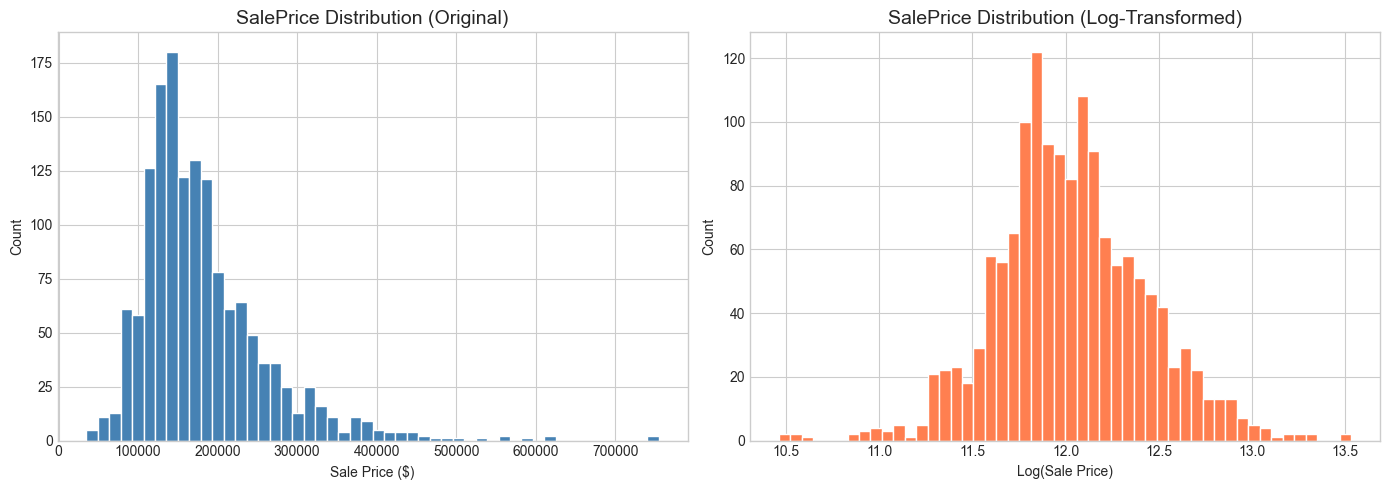

💡 Log transformation makes the distribution more normal — better for regression!


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)', fontsize=14)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-Transformed)', fontsize=14)
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Log transformation makes the distribution more normal — better for regression!')

Columns with missing values: 19


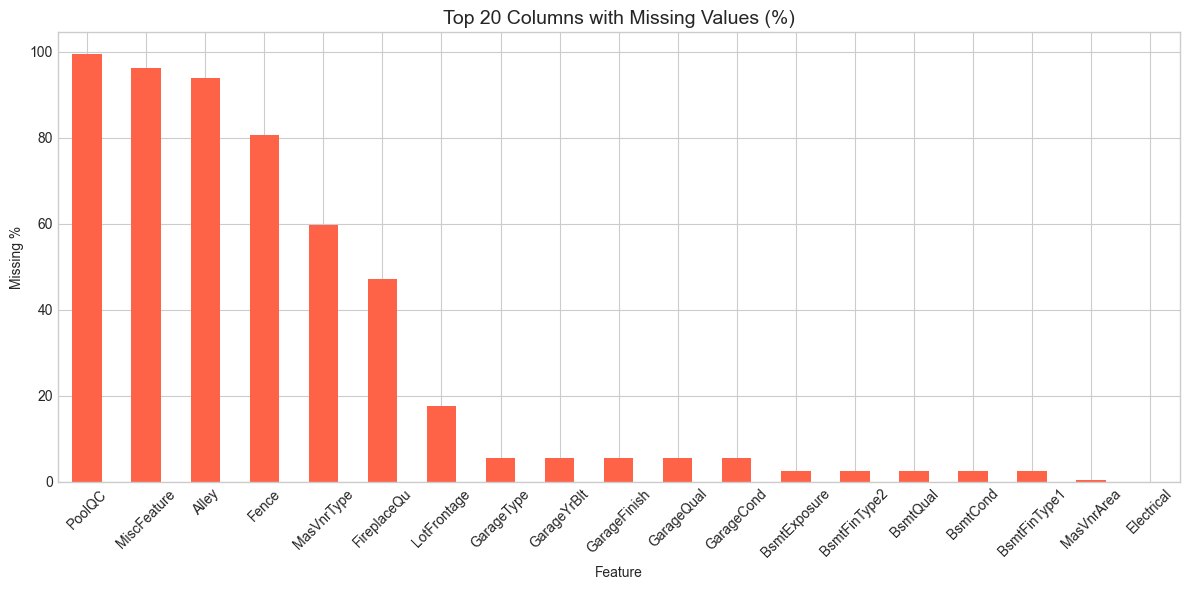

In [5]:
# Missing value analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'Columns with missing values: {len(missing_df)}')

plt.figure(figsize=(12, 6))
missing_pct.head(20).plot(kind='bar', color='tomato')
plt.title('Top 20 Columns with Missing Values (%)', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

Top 15 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


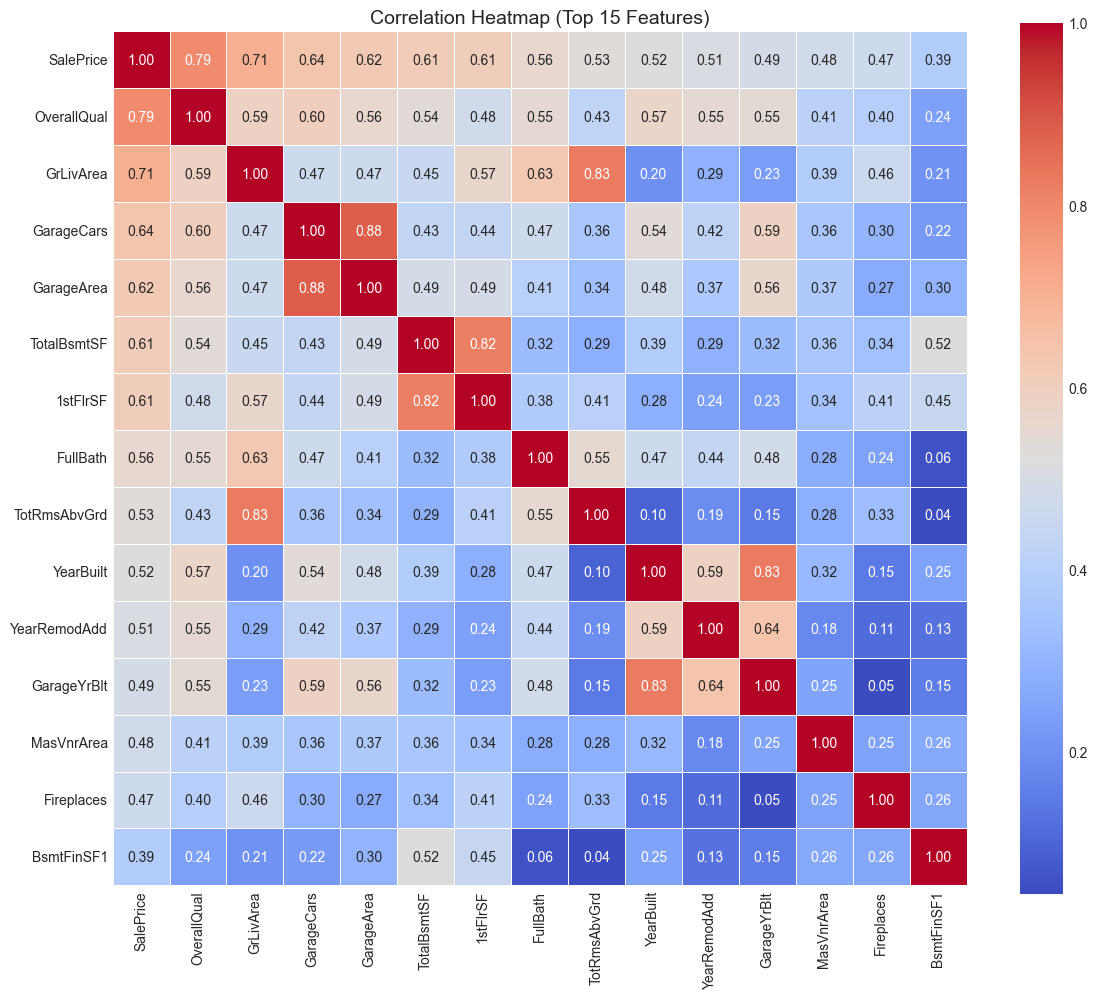

In [6]:
# Correlation heatmap (top numeric features)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Top 15 features correlated with SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(15)
print('Top 15 features correlated with SalePrice:')
print(top_corr)

plt.figure(figsize=(12, 10))
top_features = top_corr.index.tolist()
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Top 15 Features)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

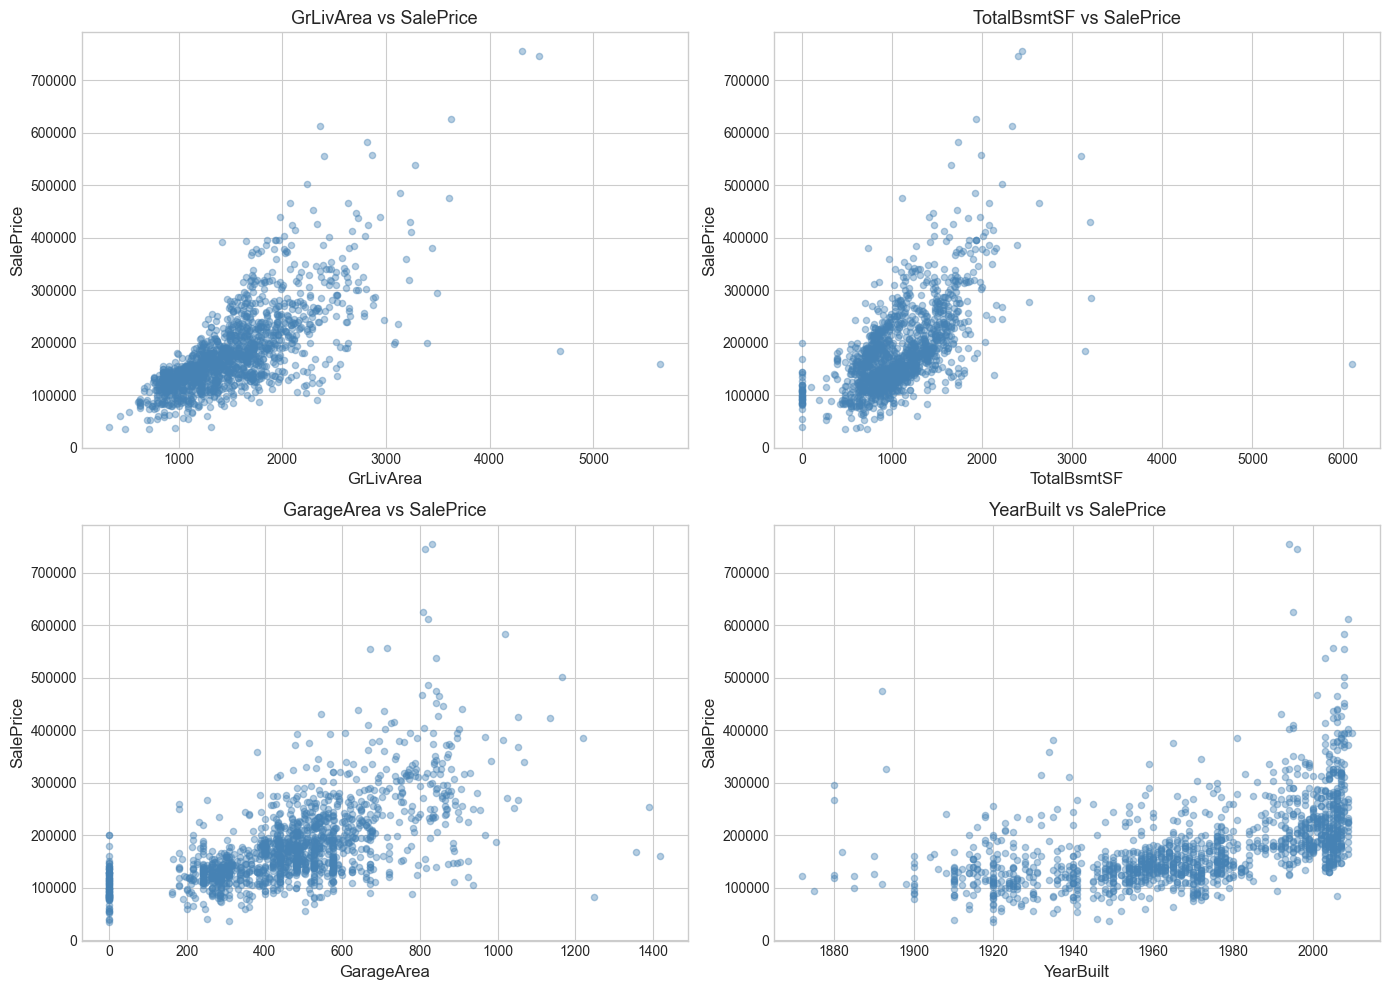

In [7]:
# Key feature scatter plots
key_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue', s=20)
    axes[i].set_xlabel(feat, fontsize=12)
    axes[i].set_ylabel('SalePrice', fontsize=12)
    axes[i].set_title(f'{feat} vs SalePrice', fontsize=13)

plt.tight_layout()
plt.savefig('../data/eda_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
def preprocess_data(df):
    df = df.copy()

    # --- Drop ID and low-value columns ---
    drop_cols = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # --- Fill missing values ---
    # Categorical: fill with 'None' (means feature doesn't exist)
    cat_none_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                     'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'MasVnrType']
    for col in cat_none_cols:
        if col in df.columns:
            df[col].fillna('None', inplace=True)

    # Numeric: fill with 0
    num_zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                     'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                     'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
    for col in num_zero_cols:
        if col in df.columns:
            df[col].fillna(0, inplace=True)

    # Fill remaining categoricals with mode
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # Fill remaining numerics with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)

    # --- Feature Engineering ---
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                       df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasPool'] = (df.get('PoolArea', pd.Series([0]*len(df))) > 0).astype(int)

    # --- Encode categoricals ---
    cat_cols = df.select_dtypes(include='object').columns
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    return df

df_clean = preprocess_data(df)
print(f'✅ Cleaned data shape: {df_clean.shape}')
print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')

✅ Cleaned data shape: (1460, 83)
Missing values remaining: 348


In [9]:
# Log-transform target (reduces skew, improves model performance)
X = df_clean.drop('SalePrice', axis=1)
y = np.log1p(df_clean['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 1168, Test size: 292


In [11]:
# Check for remaining NaN values
print("NaN values in X_train:", np.isnan(X_train_scaled).sum())
print("NaN values in X_test:", np.isnan(X_test_scaled).sum())

# Force-fill any remaining NaNs
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

print("✅ Done! NaN values remaining:", np.isnan(X_train_scaled).sum())

NaN values in X_train: 287
NaN values in X_test: 61
✅ Done! NaN values remaining: 0


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Lasso Regression':  Lasso(alpha=0.001),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).T.sort_values('RMSE')
print('\n🏆 Best Model:', results_df.index[0])

Linear Regression         | RMSE: 0.1493 | MAE: 0.1021 | R²: 0.8805
Ridge Regression          | RMSE: 0.1512 | MAE: 0.1032 | R²: 0.8776
Lasso Regression          | RMSE: 0.1499 | MAE: 0.1024 | R²: 0.8795
Random Forest             | RMSE: 0.1429 | MAE: 0.0951 | R²: 0.8906
Gradient Boosting         | RMSE: 0.1336 | MAE: 0.0881 | R²: 0.9044

🏆 Best Model: Gradient Boosting


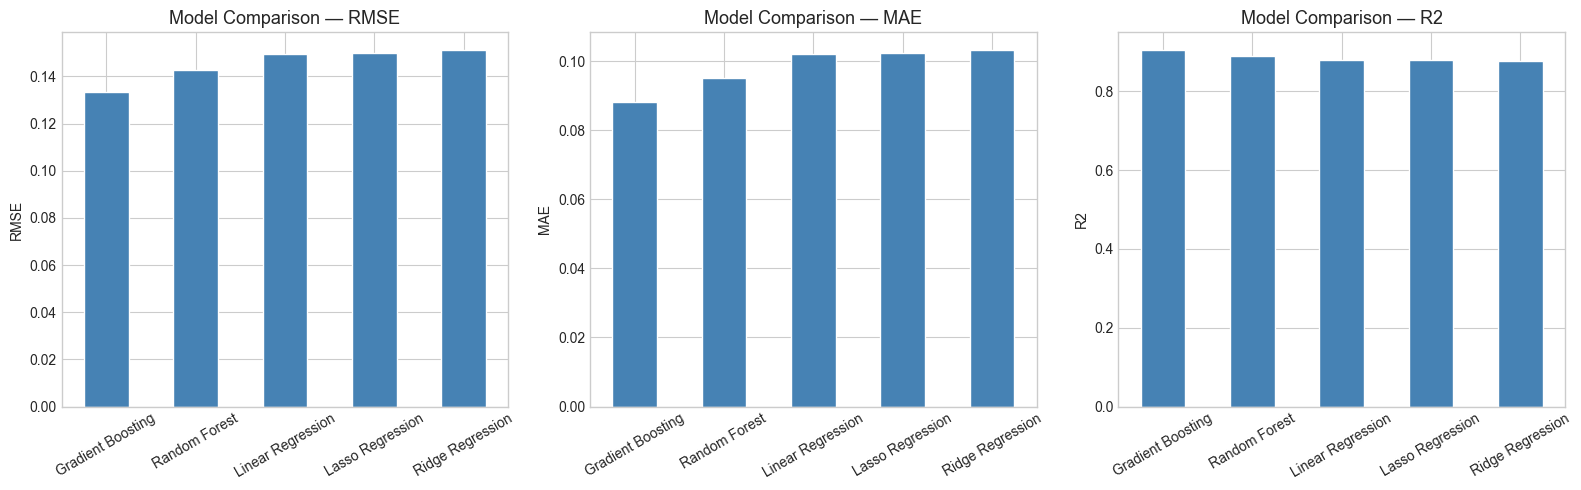

In [13]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    results_df[metric].plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Model Comparison — {metric}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

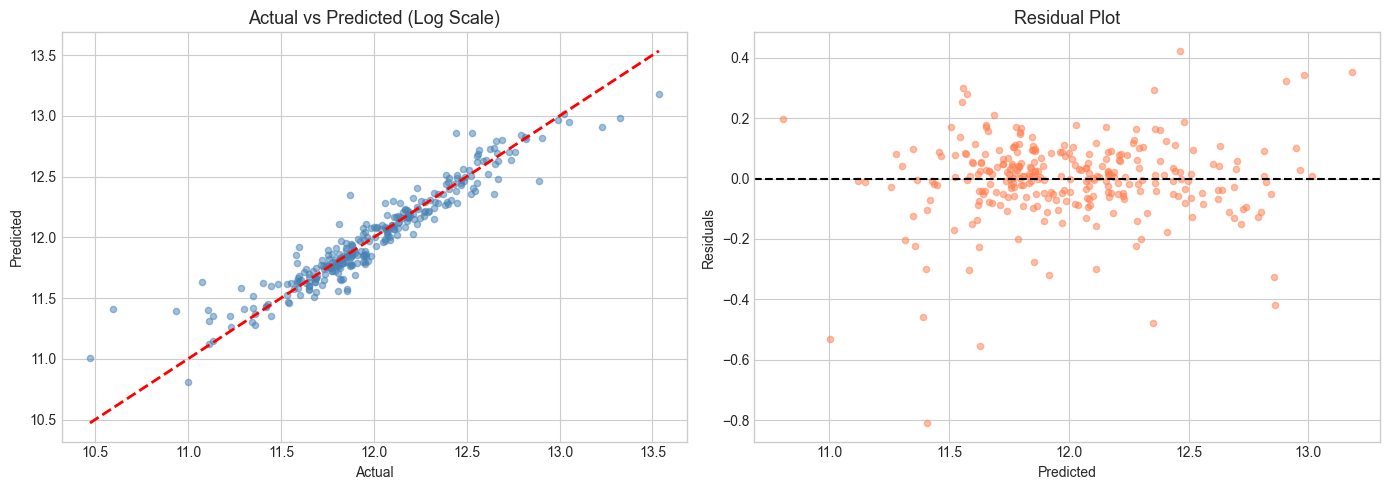

In [15]:
# Use Gradient Boosting (usually best performer)
best_model = models['Gradient Boosting']
preds = best_model.predict(X_test_scaled)

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted (Log Scale)', fontsize=13)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Residual plot
residuals = y_test - preds
axes[1].scatter(preds, residuals, alpha=0.5, color='coral', s=20)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('../data/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

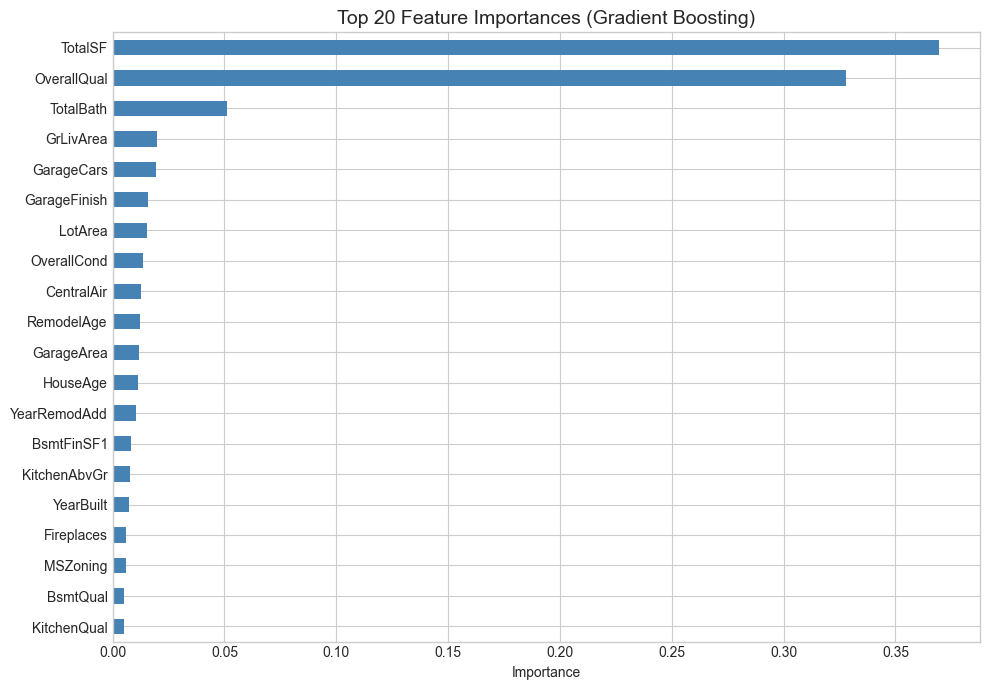

In [16]:
# Feature Importance
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Gradient Boosting)', fontsize=14)
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
joblib.dump(best_model, '../models/house_price_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')
print('✅ Model, scaler, and feature names saved to /models/')

✅ Model, scaler, and feature names saved to /models/
